# Autocorrect Keyboard System

## Objective

Develop an autocorrect keyboard system that identifies misspelled words, provides autocorrection suggestions, and predicts the next word in a sentence using N-grams.

In [24]:
!pip install pyspellchecker nltk

Defaulting to user installation because normal site-packages is not writeable


In [25]:
import nltk
from nltk.tokenize import word_tokenize
from spellchecker import SpellChecker
from nltk.util import bigrams
from collections import defaultdict
import matplotlib.pyplot as plt

nltk.download('punkt')

# Load dataset
with open(r"C:\Users\Hasini\Desktop\ShadowFox\Autocorrect_Keyboard_System\final.txt",
          "r",
          encoding="utf-8") as f:
    texts = f.readlines()

texts = [line.strip() for line in texts if line.strip()]

print("✅ Dataset Loaded")
print("Total Lines:", len(texts))


✅ Dataset Loaded
Total Lines: 113060


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Hasini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [26]:
tokens = []

for text in texts:

    words_in_sentence = [
        word.lower()
        for word in word_tokenize(text)
        if word.isalpha()
    ]

    if len(words_in_sentence) > 1:
        tokens.append(words_in_sentence)

words = []

for sentence in tokens:
    for word in sentence:
        if word.isalpha():
            words.append(word)

print("✅ Tokenization Complete")
print("Total Words:", len(words))

✅ Tokenization Complete
Total Words: 1115635


In [27]:
spell = SpellChecker()

# Add dataset vocabulary
spell.word_frequency.load_words(words)

print("✅ SpellChecker Ready")

✅ SpellChecker Ready


In [28]:
def autocorrect_text(text):

    input_words = text.split()

    corrected_words = []

    misspelled_words = []

    for word in input_words:

        if word.lower() in spell:
            corrected_words.append(word)

        else:
            correction = spell.correction(word)

            corrected_words.append(correction)

            misspelled_words.append(
                (word, correction)
            )

    return corrected_words, misspelled_words

In [29]:
bigram_model = defaultdict(lambda: defaultdict(int))

for sentence in tokens:

    for w1, w2 in bigrams(sentence):

        bigram_model[w1][w2] += 1

print("✅ Bigram Model Created")

✅ Bigram Model Created


In [30]:
def predict_next_words(word, top_n=3):

    next_words = bigram_model[word]

    if not next_words:
        return []

    total_frequency = sum(next_words.values())

    sorted_words = sorted(
        next_words.items(),
        key=lambda x: x[1],
        reverse=True
    )

    suggestions = []

    for w, freq in sorted_words[:top_n]:

        confidence = (freq / total_frequency) * 100

        suggestions.append(
            (w, round(confidence, 2))
        )

    return suggestions

In [31]:
def smart_keyboard():

    user_input = input("\nEnter your text: ")

    corrected_words, misspelled_words = autocorrect_text(
        user_input
    )

    corrected_text = " ".join(corrected_words)

    total_words = len(user_input.split())

    misspelled_count = len(misspelled_words)

    correction_rate = (
        misspelled_count / total_words
    ) * 100 if total_words > 0 else 0

    last_word = corrected_words[-1].lower()

    suggestions = predict_next_words(
        last_word,
        top_n=3
    )

    print("\n======================")
    print("ORIGINAL TEXT")
    print("======================")
    print(user_input)

    print("\n======================")
    print("CORRECTED TEXT")
    print("======================")
    print(corrected_text)

    print("\n======================")
    print("SPELLING ANALYSIS")
    print("======================")

    if misspelled_words:

        for wrong, correct in misspelled_words:

            print(
                f"{wrong} → {correct}"
            )

    else:

        print("No spelling mistakes found.")

    print("\nTotal Words:", total_words)
    print("Misspelled Words:", misspelled_count)
    print(
        "Correction Rate:",
        round(correction_rate, 2),
        "%"
    )

    print("\n======================")
    print("NEXT WORD SUGGESTIONS")
    print("======================")

    if suggestions:

        for i, (word, confidence) in enumerate(
            suggestions,
            start=1
        ):

            print(
                f"{i}. {word} ({confidence}%)"
            )

    else:

        print("No suggestions available.")

    return (
        total_words,
        misspelled_count,
        suggestions
    )

In [32]:
def visualize_results(
        total_words,
        misspelled_count,
        suggestions):

    correct_words = (
        total_words - misspelled_count
    )

    # GRAPH 1

    plt.figure(figsize=(6,4))

    plt.bar(
        ["Correct Words",
         "Misspelled Words"],
        [correct_words,
         misspelled_count]
    )

    plt.title(
        "Spelling Analysis"
    )

    plt.ylabel(
        "Word Count"
    )

    plt.show()

    # GRAPH 2

    if suggestions:

        labels = [
            word
            for word,
            conf
            in suggestions
        ]

        values = [
            conf
            for word,
            conf
            in suggestions
        ]

        plt.figure(figsize=(6,4))

        plt.bar(
            labels,
            values
        )

        plt.title(
            "Next Word Suggestion Confidence"
        )

        plt.ylabel(
            "Confidence (%)"
        )

        plt.show()


Enter your text:  I love sherlock



ORIGINAL TEXT
I love sherlock

CORRECTED TEXT
I love sherlock

SPELLING ANALYSIS
No spelling mistakes found.

Total Words: 3
Misspelled Words: 0
Correction Rate: 0.0 %

NEXT WORD SUGGESTIONS
1. holmes (100.0%)


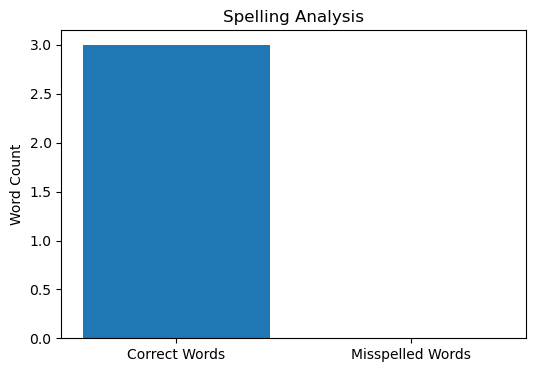

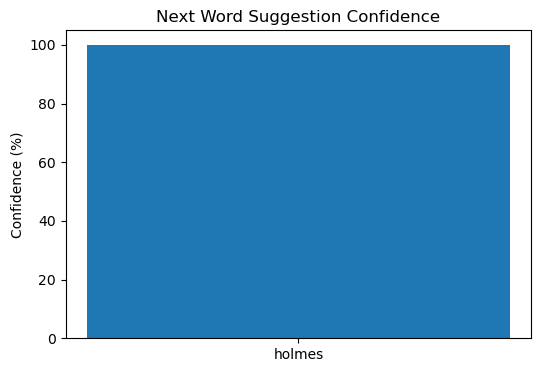

In [33]:
total_words, misspelled_count, suggestions = smart_keyboard()

visualize_results(
    total_words,
    misspelled_count,
    suggestions
)